# Analysis of the Extraction Step

### Disclosure Program Extraction

In [1]:
import pandas as pd

print("\n----- URL Extraction -----")
start_df = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/completeVDPRaw.csv')
print(f" Extracted {len(start_df)} inscope URLs from the scopes")

print("\n----- URL Subdomain Reconning -----")
start_df = start_df.copy()
df = start_df[start_df['url'].str.contains(r'\*\.', regex=True)]
df = df.copy()
df.loc[:, 'key'] = df['url'] + "-" + df['program'] + "-" + df['source']
df = df.drop_duplicates(subset='key', keep='first')  
print(f" Extracted {len(df)} Wildcards URLs from the scopes")

df_subdomains = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/found_subdomains_VDP.csv')
print(f" Enriched {len(df)} Wildcards URLs to {len(df_subdomains)} new subdomains")

print("\n----- URL Subdomain Removing -----")
df_inscope = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/found_subdomains_inscope_VDP.csv')
removed_subdomains = len(df_subdomains) - len(df_inscope)
print(f" From {len(df_subdomains)} new Subdomains {removed_subdomains} were removed as explicitly out-of-scope subdomains")
print(f" Leaving us with {len(df_inscope)} new subdomains")

print("\n----- URL Testing -----")
overall_tested = len(start_df) + len(df_inscope)
print(f" {len(start_df)} Extracted + {len(df_inscope)} Discovered Subdomains {overall_tested}")
print(f" -> BUT: From {overall_tested} - {overall_tested - 38360} thrown an error")
print(f" -> Starting testing for response code and type with 38360 (unique 36377) URLs ")
overall_tested_unqiue = 36377

# 2025-02-17 12:12:36,694 INFO: testUrls(): [*] Overall DNS Filtering: 17039/36377 have an IP Entry
valid_dns = 17039
print(f" Done testing URLs. {overall_tested_unqiue - 17039}/{overall_tested_unqiue} URLs failed due to non existing DNS entry!")

checked_df = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/VDP_test_results.csv')
df_redirects = checked_df[checked_df['Reason'].str.contains('Redirect to:', na=False)]
print(f" Done testing URLs. {len(df_redirects)}/{overall_tested_unqiue} URLs failed due to redirects!")

df_html_content = checked_df[checked_df['Reason'].str.contains('No HTML tag found', na=False)]
print(f" Done testing URLs. {len(df_html_content)}/{overall_tested_unqiue} URLs failed due to non-HTML content!")

# TODO: Read out the reasons for the other failures
print(f" Done testing URLs. {len(df_html_content)}/{overall_tested_unqiue} URLs failed due to Timeouts/Exceptions")

checked_df = checked_df[checked_df['Valid'] == "True"]
checked_df.to_csv('/home/Redacted_author/MasterThesis/code/data/inscope_reachable_VDP.csv', index=False)
print(f" Done testing URLs. {len(checked_df)}/{overall_tested_unqiue} URLs responded with valid response and content")



----- URL Extraction -----
 Extracted 65 inscope URLs from the scopes

----- URL Subdomain Reconning -----
 Extracted 0 Wildcards URLs from the scopes
 Enriched 0 Wildcards URLs to 33285 new subdomains

----- URL Subdomain Removing -----
 From 33285 new Subdomains 4821 were removed as explicitly out-of-scope subdomains
 Leaving us with 28464 new subdomains

----- URL Testing -----
 65 Extracted + 28464 Discovered Subdomains 28529
 -> BUT: From 28529 - -9831 thrown an error
 -> Starting testing for response code and type with 38360 (unique 36377) URLs 
 Done testing URLs. 19338/36377 URLs failed due to non existing DNS entry!
 Done testing URLs. 2315/36377 URLs failed due to redirects!
 Done testing URLs. 17/36377 URLs failed due to non-HTML content!
 Done testing URLs. 17/36377 URLs failed due to Timeouts/Exceptions
 Done testing URLs. 3558/36377 URLs responded with valid response and content


### CruX Extraction

In [ ]:
import pandas as pd

# Crux Extraction and Test Anaylsis 
print("\n----- URL Extraction -----")
print("-> Not needed for CRUX")

print("\n----- URL Subdomain Reconning -----")
print("-> Not needed for CRUX")

print("\n----- URL Subdomain Removing -----")
print("-> Not needed for CRUX")

print("\n----- URL Testing -----")
df = pd.read_csv("/home/Redacted_author/MasterThesis/code/data/CRUX_expanded_test_results.csv")


overall = 12000
# 2025-02-19 21:44:31,154 INFO: testUrls(): [*] Overall DNS Filtering: 11960/12000 have an IP Entry
print(f" Done testing URLs. 40/{overall} URLs failed due to non existing DNS entry!")

df_redirects = df[df['Reason'].str.contains('Redirect to:', na=False)]
print(f" Done testing URLs: {len(df_redirects)}/{overall} URLs failed due to redirects!")

df_html_content = df[df['Reason'].str.contains('No HTML tag found', na=False)]
print(f" Done testing URLs: {len(df_html_content)}/{overall} URLs failed due to non-HTML content!")

df = df[df['Valid'] == "True"]
print(f" Done testing URLs: {len(df)}/{overall} URLs responed with valid response and content")

### Headers Extraction + Request Limit Extraction for Proxy

3782


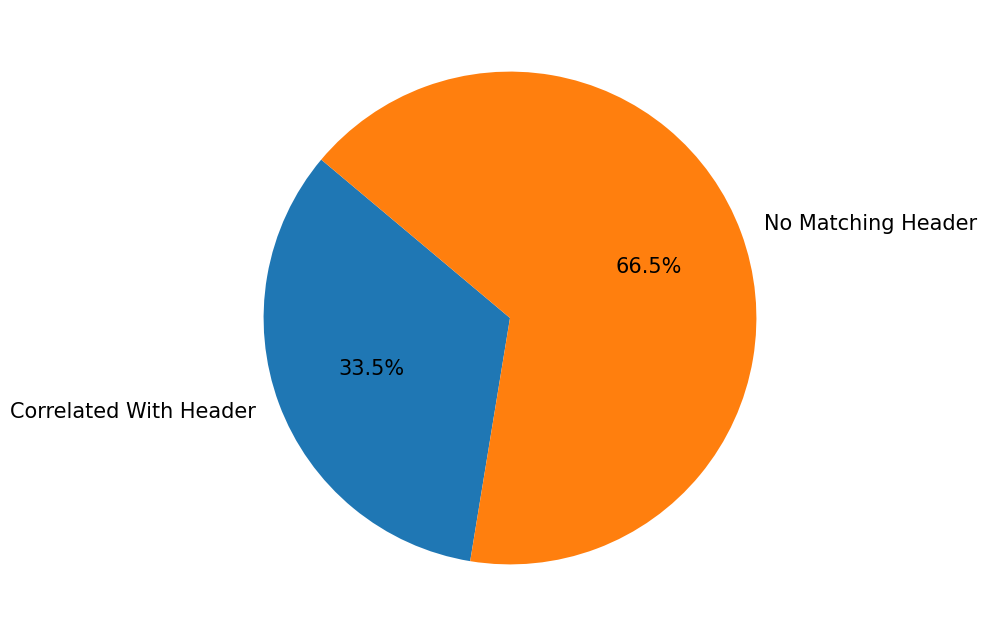

Domains for which we found a header: 2161
Of 3782 domains (webpages) collected as in scope we have a header for 1268
OVERALL number of program a (valid) Header was found: 224
Explicitly read out already
Explicitly read out already
Number of programs with a request limit found via LLM: 86
Number of programs with a request limit found via Field: 102
Overall number of programs with a request limit found : 188
Request-Limit - Average: 23.03723404255319
Request-Limit - Median: 5.0


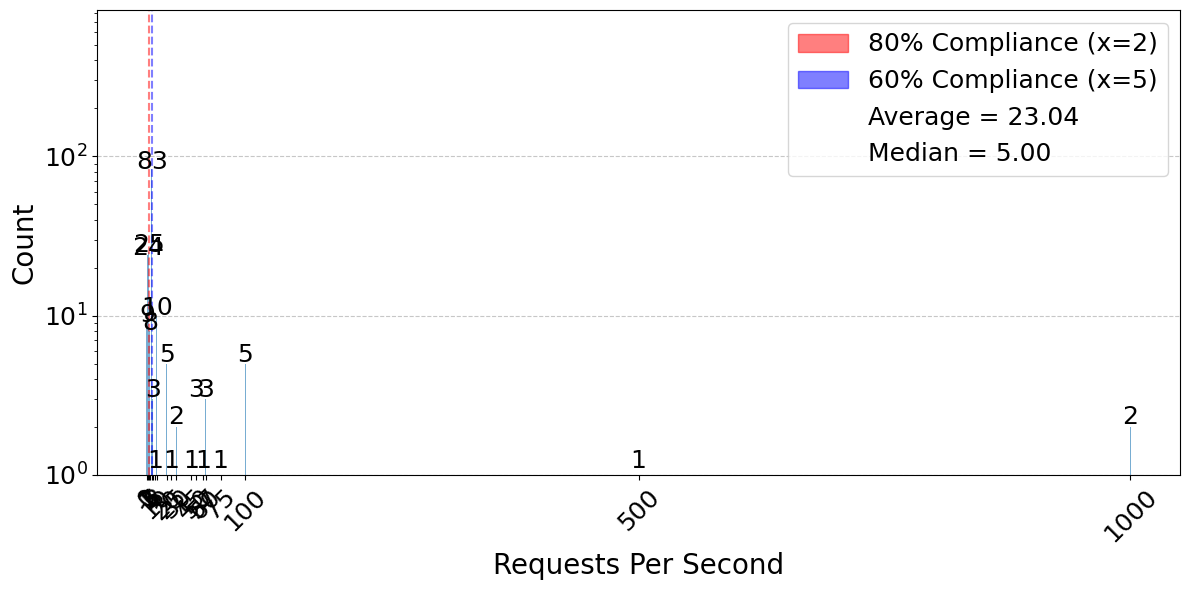

90%-Perzentil: 26.50
80%-Perzentil: 6.00
70%-Perzentil: 5.00
60%-Perzentil: 5.00
50%-Perzentil: 5.00
40%-Perzentil: 5.00
30%-Perzentil: 2.00
20%-Perzentil: 2.00
10%-Perzentil: 1.00


/tmp/ipykernel_67823/2845260477.py:207: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


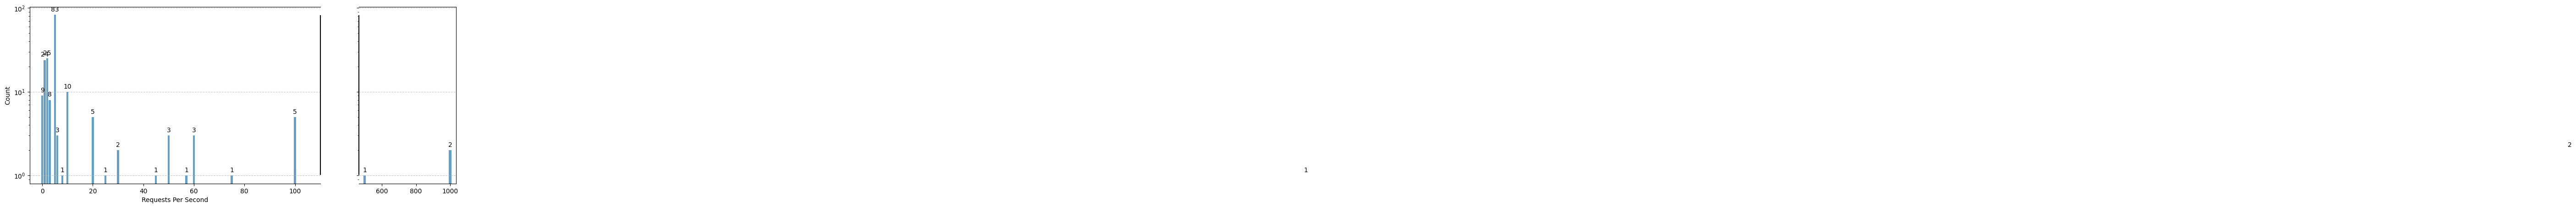

In [9]:
import pandas as pd
import tldextract
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import statistics
import numpy as np

# Create simliar table to the one used in the thesis
engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
Session = sessionmaker(bind=engine)
session = Session()

df = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/headers_scopes_correlation.csv')
df = df.drop(df[(df["header_value"] == "BugBounty") & (df["header_key"] == "User-Agent")].index)
domain_list_headers = set(df['domain'])


df = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/completeVDPRaw.csv')

def extract_domain(url):
    extracted = tldextract.extract(url)
    return f"{extracted.domain}"

df['domain'] = df['url'].apply(extract_domain)
df = df[['domain']].drop_duplicates()
domain_list_scope = set(df['domain'])
print(len(domain_list_scope))

# Calculate overlap
overlap = len(domain_list_scope & domain_list_headers)
only_in_domain_list = len(domain_list_scope - domain_list_headers)

# Pie chart visualization
labels = ['Correlated With Header', 'No Matching Header']
sizes = [overlap, only_in_domain_list]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 15})
#plt.title("Overlap Between In-Scope Domains and Domains with Extracted Headers", fontdict={'fontsize': 16})
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/header_scope_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(f'Domains for which we found a header: {len(domain_list_headers)}')
print(f'Of {len(domain_list_scope)} domains (webpages) collected as in scope we have a header for {overlap}')


# Programs with a header extracted
file_path = '/home/Redacted_author/MasterThesis/code/data/extractor/headers_found.json'
count_header = 0
with open(file_path, "r", encoding="utf-8") as file:
    json_data = json.load(file)
    for key, item in json_data.items():
        for header_key, header_value in item.items():
            if 'User-Agent' == header_key:
                if header_value == "BugBounty":
                    continue

                if header_value == "@wearehackerone.com":
                    continue

                if header_value == "@bugcrowdninja.com":
                    continue
            
            if 'Email' == header_key:
                continue
            count_header += 1
    
    print(f'OVERALL number of program a (valid) Header was found: {count_header}')


# Check how many of those are explicitly oresented and extracted without LLM
limit_list = []
init_program_req_limit_set = set()
query = "SELECT * FROM rules WHERE source!='Huoxian' and rules is not NULL"
result = session.execute(query)
df = pd.DataFrame(result.fetchall(), columns=result.keys())
df_inti = df[df['source'] == "Intigriti"]
for _, row in df_inti.iterrows():
    formated_rules = json.loads(row['rules'])
    req_limit = formated_rules['rule']["content"]['content']['testingRequirements']['automatedTooling']
    if req_limit is None:
        #print("No Header set")
        pass
    else:
        limit_list.append(int(req_limit))
        init_program_req_limit_set.add(row['programHandle'])

file_path = '/home/Redacted_author/MasterThesis/code/data/extractor/extracted_req_limits_fixed.json'
valid_count = 0
with open(file_path, "r", encoding="utf-8") as file:
    json_data = json.load(file)
    for key, value in json_data.items():
        if value is not None:
            req_limit = value['req_per_sec']
            if req_limit is None:
                    continue
            else:
                # here we might already have one explicitly set
                if key not in init_program_req_limit_set:
                    valid_count += 1
                    limit_list.append(int(req_limit))
                else:
                    print("Explicitly read out already")
                    pass
        

print(f'Number of programs with a request limit found via LLM: {valid_count}')
print(f'Number of programs with a request limit found via Field: {len(init_program_req_limit_set)}')
print(f'Overall number of programs with a request limit found : {len(init_program_req_limit_set) + valid_count}')


average = statistics.mean(limit_list)
median = statistics.median(limit_list)
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


print(f"Request-Limit - Average: {average}")
print(f"Request-Limit - Median: {median}")

lower_bound = np.percentile(limit_list, 5)
upper_bound = np.percentile(limit_list, 95)

df_counts = pd.Series(limit_list).value_counts().sort_index()
#df_counts = df_counts[df_counts.index < 500]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_counts.index, df_counts.values, width=0.8, alpha=0.6)

plt.xlabel("Requests Per Second", fontsize=20)
plt.ylabel("Count", fontsize=20)

for i, v in enumerate(df_counts.values):
    plt.text(df_counts.index[i], v + 0.1, str(v), ha='center', fontsize=18)

plt.xticks(df_counts.index, rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.ylim(1, df_counts.values.max() * 10)

# Lines
line1 = plt.axvline(x=2, color='red', alpha=0.5, linestyle='--')
line2 = plt.axvline(x=5, color='blue', alpha=0.5, linestyle='--')

# Legend handles
legend_elements = [
    mpatches.Patch(color='red', alpha=0.5, label='80% Compliance (x=2)'),
    mpatches.Patch(color='blue', alpha=0.5, label='60% Compliance (x=5)'),
    mpatches.Patch(facecolor='none', edgecolor='none', label=f'Average = {average:.2f}'),
    mpatches.Patch(facecolor='none', edgecolor='none', label=f'Median = {median:.2f}')
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=18)
plt.tight_layout()
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/req_limit_range.pdf', format='pdf', bbox_inches='tight')
plt.show()

percentiles = [90, 80, 70, 60, 50, 40, 30, 20, 10]
percentile_values = {p: np.percentile(limit_list, p) for p in percentiles}

for p, value in percentile_values.items():
    print(f"{p}%-Perzentil: {value:.2f}")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

# Linker Plot (0–20)
#df_main = df_counts[df_counts.index <= 100]
df_main = df_counts
ax1.bar(df_main.index, df_main.values, alpha=0.7)
ax1.set_xlim(-5, 110)
ax1.set_xlabel("Requests Per Second")
ax1.set_ylabel("Count")
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_yscale('log')

# Rechter Plot (>20)
df_outliers = df_counts[df_counts.index > 100]
ax2.bar(df_outliers.index, df_outliers.values, alpha=0.7, width=15)
#ax2.set_xlim(min(df_outliers.index) - 50, max(df_outliers.index) + 50)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')

# Achsen "brechen"
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Diagonale Linien zur Trennung
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot([1, 1], [0.05, 0.95], **kwargs)
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot([0, 0], [0.05, 0.95], **kwargs)

for i, v in enumerate(df_main.values):
    ax1.text(df_main.index[i], v * 1.1, str(v), ha='center', fontsize=10)

for i, v in enumerate(df_outliers.values):
    ax2.text(df_outliers.index[i], v * 1.1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Table for Data Processing

In [9]:
# Website Extracting and Testing Step
import pandas as pd
import tldextract
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import statistics
import numpy as np

# Print len of the different lists for the table

# Scope Entries
engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
Session = sessionmaker(bind=engine)
session = Session()
query = "SELECT * FROM scopes WHERE inScope='1'"
result = session.execute(query)
df = pd.DataFrame(result.fetchall(), columns=result.keys())
print(f'VDP - Scope Entries: {len(df)}')
print(f'CRUX - Scope Entries: 12000')

''' FIX FOR INTI FAILURE:
Initgriti - OOS Scope Entries treated as in-scope: 412
Anzahl an extrahierten (falsch) Scopes: 375
Anzahl an extrahierten (falsch) Scopes Wildcards: 15
Anzahl Subdomains needed to get removed: 651
Anzahl URLS needed to get removed overall: 1026
One that mnight need to be removed: 271
Valid One that need to be removed: 96
'''
inti_wrong_scopes = 412
inti_wrong_wildcards = 15
inti_wrong_subdomains = 651
inti_wrong_valid_response = 96


# Extracted Webpages
print()
df_extracted_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/completeVDPRaw.csv')
df_extracted_VDP = df_extracted_VDP[df_extracted_VDP['source']=="BB"]
df_extracted_CRUX = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/extracted_urls_CRUX.csv')
print(f'VDP - Extracted Webpages from it: {len(df_extracted_VDP)}')
print(f'CRUX - Extracted Webpages from it: 12000')

# Wildcards
print()
df_discovered_subdomains_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_VDP.csv')
print(f'VDP - Potential Wildcards extracted; {len(set(df_discovered_subdomains_VDP['key'])) - inti_wrong_wildcards}')
print(f'CRUX - Potential Wildcards extracted; 0')

# Discovered Subdomains
print()
df_discovered_subdomains_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_VDP.csv')
print(f'VDP - Potential Subdomains discovered: {len(set(df_discovered_subdomains_VDP['url'])) - inti_wrong_subdomains}')
print(f'CRUX - Potential Subdomains discovered: 0')

# Removed Scopes (due to out-of-scope)
print()
df_discovered_subdomains_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_VDP.csv')
df_discovered_subdomains_inscope_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_inscope_VDP.csv')
print(f"VDP - Valid Subdomains discovered: {len(set(df_discovered_subdomains_inscope_VDP['url']))} - ({len(set(df_discovered_subdomains_VDP['url'])) - len(set(df_discovered_subdomains_inscope_VDP['url']))} URLs Removode Out-Of-scope)")
overall_tested_VDP = set(df_discovered_subdomains_inscope_VDP['url']) | set(df_extracted_VDP['url'])
print(f"VDP - SUMMED: unique {len(overall_tested_VDP)} -> {len(set(df_discovered_subdomains_inscope_VDP['url']))} discovered + {len(df_extracted_VDP)} Base")
print(f'CRUX - Valid Subdomains discovered: 0')


# Removed Scopes (due to No DNS Entry or no valid content oder Redirecteon or no Response)
print()
checked_df_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/VDP_test_results.csv')
checked_df_CRUX = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/CRUX_expanded_test_results.csv')

# overall_tested_VDP = 37996
# VDP: From the logs: 17039/36377 have an IP Entry
# CRUX: From the logs: 11960/12000 have an IP Entry
valid_DNS_VDP = 17039
valid_DNS_CRUX = 11960
print(f'VDP - DNS Based FIltering - Target with IP: {valid_DNS_VDP}') # and {37996 - 36377} Exceptions/Timeouts
print(f'CRUX - DNS Based FIltering - Target with IP: {valid_DNS_CRUX}') # and 0 Exceptions/Timeouts ??

print()
error_VDP =  checked_df_VDP[checked_df_VDP['Valid'] != "True"]
valid_VDP =  checked_df_VDP[checked_df_VDP['Valid'] == "True"]
df_redirects_VDP = checked_df_VDP[checked_df_VDP['Reason'].str.contains('Redirect to:', na=False)]
df_html_content_VDP = checked_df_VDP[checked_df_VDP['Reason'].str.contains('No HTML tag found', na=False)]
print(f'VDP - HTTP FIltering - Valid: {len(valid_VDP) - inti_wrong_valid_response}')
print(f'VDP - HTTP FIltering - Invalid Overall: {len(error_VDP)}')
print(f' VDP - HTTP FIltering - Redirects: {len(df_redirects_VDP)}')
print(f' VDP - HTTP FIltering - Non HTML: {len(df_html_content_VDP)}')

print()
error_CRUX = checked_df_CRUX[checked_df_CRUX['Valid'] != "True"]
valid_CRUX = checked_df_CRUX[checked_df_CRUX['Valid'] == "True"]
df_redirects_CRUX = checked_df_CRUX[checked_df_CRUX['Reason'].str.contains('Redirect to:', na=False)]
df_html_content_CRUX = checked_df_CRUX[checked_df_CRUX['Reason'].str.contains('No HTML tag found', na=False)]
print(f'CRUX - HTTP FIltering - Valid: {len(valid_CRUX)}')
print(f'CRUX - HTTP FIltering - Invalid Overall: {len(error_CRUX)}')
print(f' CRUX - HTTP FIltering - Redirects: {len(df_redirects_CRUX)}')
print(f' CRUX - HTTP FIltering - Non HTML: {len(df_html_content_CRUX)} ')

# final = 3558 VDP URLS

session.close()

VDP - Scope Entries: 11975
CRUX - Scope Entries: 12000

VDP - Extracted Webpages from it: 9919
CRUX - Extracted Webpages from it: 12000

VDP - Potential Wildcards extracted; 104
CRUX - Potential Wildcards extracted; 0

VDP - Potential Subdomains discovered: 32615
CRUX - Potential Subdomains discovered: 0

VDP - Valid Subdomains discovered: 28445 - (4821 URLs Removode Out-Of-scope)
VDP - SUMMED: unique 37996 -> 28445 discovered + 9919 Base
CRUX - Valid Subdomains discovered: 0

VDP - DNS Based FIltering - Target with IP: 17039
CRUX - DNS Based FIltering - Target with IP: 11960

VDP - HTTP FIltering - Valid: 3462
VDP - HTTP FIltering - Invalid Overall: 9027
 VDP - HTTP FIltering - Redirects: 2315
 VDP - HTTP FIltering - Non HTML: 17

CRUX - HTTP FIltering - Valid: 9423
CRUX - HTTP FIltering - Invalid Overall: 2189
 CRUX - HTTP FIltering - Redirects: 1005
 CRUX - HTTP FIltering - Non HTML: 0 


In [ ]:
### This is for sampling testing the results 

import pandas as pd
import tldextract
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import statistics
import numpy as np
engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
Session = sessionmaker(bind=engine)
session = Session()
query = "SELECT * FROM rules WHERE source!='Huoxian' and rules is not NULL"
result = session.execute(query)
df = pd.DataFrame(result.fetchall(), columns=result.keys())
session.close()
df_sample = df.sample(n=min(15, len(df)), random_state=1)
print(df_sample['programHandle'])

# HEADERS
'''
 usertesting -> No Header found - No Header contained
 spotify -> No Header found - No Header contained
 engagements/sophos -> No Header found - No Header contained
 simscale -> No Header found - No Header contained
 equifax -> No Header found - No Header contained
 humo -> Header found - Right Header found 
 discourse -> Header found -  No Header contained
 slack ->  No Header found - No Header contained
 engagements/eazybi -> !!! "User-Agent": "bugcrowdninja.com" -> No header contained
 harman-international-web-applications -> No Header found - No Header contained
 engagements/coindesk-mbb-og ->  No Header found - No Header contained
 engagements/classdojo ->  Header found - Contained: [UA-BUGCROWD]
 nba-public - No Header found - No Header contained
 pfizer - No Header found - No Header contained
 one_zero_vdp - No Header found - No Header contained
'''


# REQUESTS 
'''
 usertesting -> No limit found - No limit contained
 spotify -> No limit found - No limit contained
 engagements/sophos -> No limit found - No limit contained
 simscale -> No limit found - No limit contained (Not for LLM) -> explictily read out due to filed set
 equifax -> No limit found - No limit contained
 humo -> No limit found - No limit contained (Not for LLM) -> explictily read out due to filed set
 discourse  -> No limit found - No limit contained (Not for LLM) -> explictily read out due to filed set
 slack -> No limit found - No limit contained
 engagements/eazybi -> No limit found - No limit contained
 harman-international-web-applications -> No Header found - No Header contained
 engagements/coindesk-mbb-og -> No limit found - No limit contained
 engagements/classdojo -> Limit of 1 found - Limit also containd
 nba-public -> Limit of 3 found - Correct limit
 pfizer - No limit found - No limit contained
 one_zero_vdp - - No limit found - No limit contained
'''


# Reasons for HTTP filtering 

In [22]:
import pandas as pd
import tldextract
from collections import Counter


crux_http_filtering = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/CRUX_expanded_test_results.csv')
vdp_http_filtering = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/VDP_test_results.csv')

# We only want to investigate the ones without success
crux_counts_df = crux_http_filtering[crux_http_filtering['Valid'] != "True"]
vdp_counts_df = vdp_http_filtering[vdp_http_filtering['Valid'] != "True"]

def extractDomain(url):
    extracted = tldextract.extract(url)
    if extracted.subdomain:  # If a subdomain exists, include it
        return f'{extracted.subdomain}.{extracted.domain}.{extracted.suffix}'
    return f'{extracted.domain}.{extracted.suffix}'  # Otherwise, return only domain and suffix

print("CRUX")
redirected_to = []
for _, row in crux_counts_df.iterrows():
    reason = row['Reason']
    if isinstance(reason, str) and 'Redirect' in reason:
        parts = reason.split(": ", 1)
        if len(parts) > 1:
            redirected_to.append(extractDomain(parts[1]))

redirect_counts = Counter(redirected_to)
df_redirect_counts = pd.DataFrame(redirect_counts.items(), columns=["Domain", "Count"])
df_redirect_counts = df_redirect_counts.sort_values(by="Count", ascending=False)
print(df_redirect_counts)

print()
print("VDP")
redirected_to = []
for _, row in vdp_counts_df.iterrows():
    reason = row['Reason']
    if isinstance(reason, str) and 'Redirect' in reason:
        parts = reason.split(": ", 1)
        if len(parts) > 1:
            redirected_to.append(extractDomain(parts[1]))

redirect_counts = Counter(redirected_to)
df_redirect_counts = pd.DataFrame(redirect_counts.items(), columns=["Domain", "Count"])
df_redirect_counts = df_redirect_counts.sort_values(by="Count", ascending=False)
print(df_redirect_counts)

CRUX
                        Domain  Count
25           consent.yahoo.com     45
22         accounts.google.com     18
16       myprivacy.dpgmedia.nl     11
47                xhamster.com     10
0          x3.simontokx.com.co     10
..                         ...    ...
298    www.mercadolibre.com.ar      1
299                lootlabs.gg      1
300       www.elcolombiano.com      1
301  nvidiagameworks.github.io      1
292         en.m.wikipedia.org      1

[714 rows x 2 columns]

VDP
                          Domain  Count
16             consent.yahoo.com    264
9     www.northwesternmutual.com     60
30           accounts.google.com     44
17     login.microsoftonline.com     41
147                 squareup.com     41
..                           ...    ...
824                 www.kayak.de      1
825  www.pepsicoproductfacts.com      1
826           www.servicenow.com      1
827            www.skyscanner.no      1
828                     krisp.ai      1

[852 rows x 2 columns]


----------

In [ ]:
import re
import json

log_file = "/home/Redacted_author/MasterThesis/code/logs/Scrapper-2025-03-10.log"  # Replace with the actual log file path
output_json = "extracted_data_fix.json"
data = {}
# Regular expression pattern to match log entries
pattern = re.compile(r"Extracted information for (\S+): (\{.*?\})")

# Read and parse the log file
name_set = set()
failed_count = 0
with open(log_file, "r", encoding="utf-8") as file:
    for line in file:
        match = pattern.search(line)
        if match:
            name = match.group(1) 
            json_string = match.group(2)
            json_string = json_string.replace("None", "null").replace("'", '"')

            try:
                json_data = json.loads(json_string)
                if name not in name_set:
                    data[name] = json_data
                    name_set.add(name)
            except json.JSONDecodeError as e:
                failed_count += 1
                print(f'Errro for program: {name} - {json_string}')

# Save the extracted data to a JSON file
with open(output_json, "w", encoding="utf-8") as json_file:
    json.dump(data, json_file, indent=4)
    print(len(list(data.keys())))
    print(list(data.keys()))



print(f"Extracted data saved to {output_json}")


# Check Overlap of collected Dataset and Public Datasets

[('programs',), ('reports',), ('users',), ('scopes',), ('bounties',), ('rules',), ('vulnerabilityTypes',), ('backups',)]
[('programs',), ('scopes',)]
[('programs',), ('scopes',)]
[('programs',), ('scopes',)]
Comparison with BBData:
 - OurData URLs: 8512
 - BBData URLs: 34478
 - Matching URLs: 7510 (88.23% overlap)

Comparison with PDData:
 - OurData URLs: 8512
 - PDData URLs: 4116
 - Matching URLs: 898 (10.55% overlap)

Comparison with FBData:
 - OurData URLs: 8512
 - FBData URLs: 4912
 - Matching URLs: 2177 (25.58% overlap)



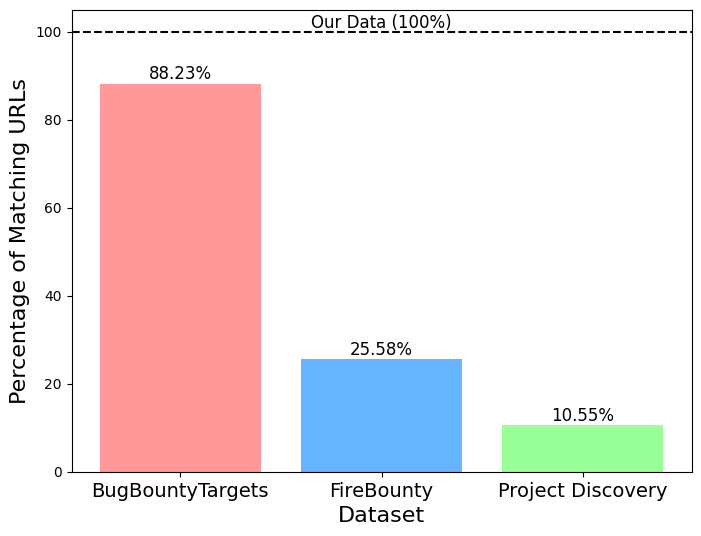

In [2]:
import re 
from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import tldextract

# Set project root directory dynamically
project_root = os.path.abspath("..")  # Adjust path if needed
if project_root not in sys.path:
    sys.path.append(project_root)

def check_tables(database_path):
    engine = create_engine(f"sqlite:///{database_path}")
    Session = sessionmaker(bind=engine)
    session = Session()
    # Create a connection to the database
    query = "SELECT name FROM sqlite_master WHERE type='table'"
    result = session.execute(query)
    print(result.fetchall())
    session.close()


def extractBBUrls():
        # Query the database
        engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
        Session = sessionmaker(bind=engine)
        session = Session()
        query = "SELECT * FROM scopes WHERE inScope='1'"
        # Execute the query and fetch results
        result = session.execute(query)
        df = pd.DataFrame(result.fetchall(), columns=result.keys())
        session.close()

        filtered_urls = []
        for _ , row in df.iterrows():
            filtered_urls.extend(filterUrls(row))
            
        # Print the valid URLs
        return filtered_urls

def extractFBUrls():
    # Query the database
    engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/FireBountyData.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractPDUrls():
    # Query the database

    engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/ProjectDiscoveryData.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    # Execute the query and fetch results
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def extractBBTUrls():
    # Query the database

    engine = create_engine('sqlite://///home/Redacted_author/MasterThesis/code/data/BugBountyTargets.sqlite')
    Session = sessionmaker(bind=engine)
    session = Session()
    query = "SELECT * FROM scopes WHERE inScope='1'"
    result = session.execute(query)
    df = pd.DataFrame(result.fetchall(), columns=result.keys())
    session.close()

    filtered_urls = []
    for _, row in df.iterrows():
        filtered_urls.extend(filterUrls(row))
        
    # Print the valid URLs
    return filtered_urls

def filterUrls(row):
        filtered_urls = []

        try:
            # Regular expression to match URLs 
            url_pattern = re.compile(
                r'(?i)\b(?:https?://|http://|www\.|\*\.)?'  # Matches http, https, www, or *.
                r'(?:[a-z0-9-]+\.)*\*?'                    # Matches subdomains and optional wildcard (*).
                r'[a-z0-9-]+'                              # Matches the main domain.
                r'(\.\*|(?:\.[a-z0-9-]+)+)'                # Matches TLDs like .com, .*, or wildcards in middle segments like shop.*.be.
                r'(:\d+)?'                                 # Matches optional port numbers.
                r'(/.*)?'                                  # Matches paths, including wildcards like /*.
            )

            valid_urls = []
            scope_entry = row.scope
            # Find all URLs in the entry
            urls = [match.group() for match in url_pattern.finditer(scope_entry)]
            valid_urls.extend(urls)

            # Add filtering for apps and github: 
            for url in valid_urls:
                if "github.com" in url:
                    continue

                if "play.google.com/store/" in url:
                    continue
                
                if "apps.apple.com/" in url:
                    continue

                if "marketplace.atlassian" in url:
                    continue

                # check for schemes
                crafted_url = url
                if not "http://" in url and not "https://" in url:
                    crafted_url = "http://" + url

                # check for wildcards
                if "*." in crafted_url:
                    filtered_urls.append([crafted_url, row.programHandle])
                    crafted_url = crafted_url.replace("*.", "").strip()
                        
                filtered_urls.append([crafted_url, row.programHandle])
            
            return filtered_urls
        
        except Exception as e:
            print(f"[!] Exception during filtering/extracting URLs of colleted entries: {e}")
            return filtered_urls


check_tables('/home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
check_tables('/home/Redacted_author/MasterThesis/code/data/BugBountyTargets.sqlite')
check_tables('/home/Redacted_author/MasterThesis/code/data/ProjectDiscoveryData.sqlite')
check_tables('/home/Redacted_author/MasterThesis/code/data/FireBountyData.sqlite')

OurData = extractBBUrls()
BBData = extractBBTUrls()
PDData = extractPDUrls()
FBData = extractFBUrls()


def normalize(url):
    url = url.replace("https://", "")
    url = url.replace("http://", "")
    url = url.replace("www.", "")

    extracted = tldextract.extract(url)
    return f"{extracted.subdomain}{extracted.domain}.{extracted.suffix}"
    

def compare_urls(our_data, other_data, other_name):
    # Convert to set for fast lookup
    our_urls = set([normalize(x[0]) for x in our_data])
    other_urls = set([normalize(x[0]) for x in other_data])


    # Find intersections
    common_urls = our_urls.intersection(other_urls)

    # Print results
    print(f"Comparison with {other_name}:")
    print(f" - OurData URLs: {len(our_urls)}")
    print(f" - {other_name} URLs: {len(other_urls)}")
    print(f" - Matching URLs: {len(common_urls)} ({len(common_urls) / len(our_urls) * 100:.2f}% overlap)\n")

    '''
    labels = ["Contained in Our and Their Dataset", "URLs only in our Dataset"]
    colors = ["#ff9999", "#66b3ff"]
    unique_urls = len(our_urls) - len(common_urls) 
    sizes = [len(common_urls), unique_urls]    
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
    plt.title("URL Overlap Analysis")
    plt.show()
    '''

    return len(common_urls), len(our_urls), len(other_urls)

# Perform comparisons

# BBTarget collects from all Source we have + More
res = compare_urls(OurData, BBData, "BBData")
first_bar = res[0] / res[1] * 100

# PD  - Does not list the sources
res = compare_urls(OurData, PDData, "PDData")
sec_bar = res[0] / res[1] * 100

# FB  - Does not list the sources
res = compare_urls(OurData, FBData, "FBData")
third_bar = res[0] / res[1] * 100

labels = ["BugBountyTargets", "FireBounty", "Project Discovery"]
sizes = [first_bar, third_bar, sec_bar]
colors = ["#ff9999", "#66b3ff"]
plt.figure(figsize=(8,6))
bars = plt.bar(labels, sizes, color=["#ff9999", "#66b3ff", "#99ff99"])

# Add percentages on top of bars
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f"{size:.2f}%", ha='center', fontsize=12)

plt.bar(labels, sizes, color=["#ff9999", "#66b3ff", "#99ff99"])
plt.axhline(y=100, color="black", linestyle="dashed", linewidth=1.5)
plt.text(1, 101, "Our Data (100%)", ha="center", fontsize=12)
plt.xlabel("Dataset", fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel("Percentage of Matching URLs", fontsize=16)
#plt.title("Comparison of URL Overlaps with our Collected Data")
plt.savefig('/home/Redacted_author/MasterThesis/latex/MasterThesis/master/resources/other_datasets_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [3]:
# FIX ERROR OF INTIGRITI
import re
import pandas as pd
import tldextract

from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine


# Identify the oos URLs which were treated as inscope and all the subdomains
# Scope Entries
engine = create_engine('sqlite:////home/Redacted_author/MasterThesis/code/data/BugBountyData.sqlite')
Session = sessionmaker(bind=engine)
session = Session()
query = "SELECT * FROM scopes WHERE inScope='0'"
result = session.execute(query)
df = pd.DataFrame(result.fetchall(), columns=result.keys())
df = df[df['source'] == 'Intigriti']
print(f'Initgriti - OOS Scope Entries treated as in-scope: {len(df)}')

# Extracted URLs from them:
def filterUrls(row):
        filtered_urls = []

        try:
            # Regular expression to match URLs 
            url_pattern = re.compile(
                r'(?i)\b(?:https?://|http://|www\.|\*\.)?'  # Matches http, https, www, or *.
                r'(?:[a-z0-9-]+\.)*\*?'                    # Matches subdomains and optional wildcard (*).
                r'[a-z0-9-]+'                              # Matches the main domain.
                r'(\.\*|(?:\.[a-z0-9-]+)+)'                # Matches TLDs like .com, .*, or wildcards in middle segments like shop.*.be.
                r'(:\d+)?'                                 # Matches optional port numbers.
                r'(/.*)?'                                  # Matches paths, including wildcards like /*.
            )

            valid_urls = []
            scope_entry = row.scope
            # Find all URLs in the entry
            urls = [match.group() for match in url_pattern.finditer(scope_entry)]
            valid_urls.extend(urls)

            # Add filtering for apps and github: 
            for url in valid_urls:
                if "github.com" in url:
                    continue

                if "play.google.com/store/" in url:
                    continue
                
                if "apps.apple.com/" in url:
                    continue

                if "marketplace.atlassian" in url:
                    continue

                # check for schemes
                crafted_url = url
                if not "http://" in url and not "https://" in url:
                    crafted_url = "http://" + url

                # check for wildcards
                if "*." in crafted_url:
                    filtered_urls.append([crafted_url, row.programHandle])
                    crafted_url = crafted_url.replace("*.", "").strip()
                        
                filtered_urls.append([crafted_url, row.programHandle])
            
            return filtered_urls
        
        except Exception as e:
            print(f"[!] Exception during filtering/extracting URLs of colleted entries: {e}")
            return filtered_urls

filtered_urls = set()
wildcards = set()
for _, row in df.iterrows():
    results = filterUrls(row)
    for url in results:
        if "*" in url[0]:
            wildcards.add(url[0])
        filtered_urls.add(url[0])

#print(filtered_urls)
print(f'Anzahl an extrahierten (falsch) Scopes: {len(set(filtered_urls))}')
print(f'Anzahl an extrahierten (falsch) Scopes Wildcards: {len(wildcards)}')
# check if there are wildcards in there subdomain discovery list
df_discovered_subdomains_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_VDP.csv')
df_discovered_subdomains_inscope_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/found_subdomains_inscope_VDP.csv')

# Extract wildcard value correctly
df_discovered_subdomains_VDP['wildcard'] = df_discovered_subdomains_VDP['key'].apply(lambda x: x.split("-", 1)[0] if isinstance(x, str) else x)
# Iterate over wildcards and filter
remove_set = set()
for wildcard in wildcards:
    filtered_df = df_discovered_subdomains_VDP[df_discovered_subdomains_VDP['wildcard'] == wildcard]
    remove_set = remove_set | set(filtered_df['url'])

print(f'Anzahl Subdomains needed to get removed: {len(remove_set)}')
remove_set = remove_set | set(filtered_urls)
print(f'Anzahl URLS needed to get removed overall: {len(remove_set)}')



def extractDomain(url):
    extracted = tldextract.extract(url)
    if extracted.subdomain:  # If a subdomain exists, include it
        return f'{extracted.subdomain}.{extracted.domain}.{extracted.suffix}'
    return f'{extracted.domain}.{extracted.suffix}'  # Otherwise, return only domain and suffix

checked_df_VDP = pd.read_csv('/home/Redacted_author/MasterThesis/code/data/bk/VDP_test_results.csv')
checked_df_VDP['domain'] = checked_df_VDP['url'].apply(extractDomain)
filtered_df = checked_df_VDP[checked_df_VDP['domain'].isin(remove_set)]
print(f'One that mnight need to be removed: {len(filtered_df)}')


valid_VDP =  checked_df_VDP[checked_df_VDP['Valid'] == "True"]
filtered_df = valid_VDP[valid_VDP['domain'].isin(remove_set)]
print(f'Valid One that need to be removed: {len(filtered_df)}')
filter_list = list(filtered_df['url'])
print(list(filtered_df['url']))

import sqlite3
db_path = "/home/Redacted_author/MasterThesis/code/data/CollectedData.sqlite"
query = "SELECT url, base_url FROM urls WHERE source='BB'"
conn = sqlite3.connect(db_path)
chunksize = 2500
entries_num = 0
count_remove = 0
urls_to_remove = set()
for chunk in pd.read_sql_query(query, conn, chunksize=chunksize):    
    print(f"Processed chunk of size: {len(chunk)}")
    print(f"Number of Entries to Remove: {count_remove}")
    entries_num = entries_num + len(chunk) 

    for _, row in chunk.iterrows():
        if row['url'] in filter_list:
            urls_to_remove
            urls_to_remove.add(row['url'])
            count_remove += 1
        
        if row['base_url'] in filter_list:
            urls_to_remove.add(row['url'])
            count_remove += 1




Initgriti - OOS Scope Entries treated as in-scope: 412
Anzahl an extrahierten (falsch) Scopes: 375
Anzahl an extrahierten (falsch) Scopes Wildcards: 15
Anzahl Subdomains needed to get removed: 651
Anzahl URLS needed to get removed overall: 1026
One that mnight need to be removed: 271
Valid One that need to be removed: 96
['http://www.vlaanderen.be', 'http://kaleidos-test.vlaanderen.be', 'http://rampenfonds-tst.vlaanderen.be', 'http://eindtermen.vlaanderen.be', 'http://inkom.vlaanderen.be', 'http://prod.frontend.burgerprofiel.vlaanderen.be', 'http://overlegcomite-dev.vlaanderen.be', 'http://basisregisters.vlaanderen.be', 'http://bibis5.vlaanderen.be', 'http://dov.vlaanderen.be', 'http://codex.vlaanderen.be', 'http://data.vlaanderen.be', 'http://beslissingenvlaamseregering.vlaanderen.be', 'http://beheer-tst-rampenfonds.vlaanderen.be', 'http://chat.contactcenter.vlaanderen.be', 'http://data.cbb-ontwikkel.omgeving.vlaanderen.be', 'http://redirects.vlaanderen.be', 'http://gelinkt-notuleren.